# ⌚ Fitbit Fitness Tracker Data — Cleaning & Exploratory Data Analysis
**Data:** Fitabase export of 33 Fitbit users, 12 Apr – 12 May 2016 (daily, hourly, minute-level activity, sleep, weight, heart rate).

**Questions explored**
1. How active are people, and what does a typical day look like?
2. *When* do they move (day of week, hour of day)?
3. How do activity and sleep relate?
4. Which user segments exist, and how consistently do people wear the device?
5. What do heart rate and weight data add — and how reliable are they?

**Scope decision:** the ~500 MB of minute/second-level files are redundant with the daily/hourly tables (verified: `dailyActivity` is a superset of `dailyCalories/Steps/Intensities`), so the analysis uses the six small tables plus heart rate aggregated to hourly. This keeps everything fast and deployable.

**Structure:** 1 Setup · 2 Load & profile · 3 Cleaning · 4 Daily activity · 5 Time of day · 6 Sleep · 7 Users & segments · 8 Heart rate & weight · 9 Correlations · 10 Findings · 11 Export

## 1. Setup

In [1]:
import sys; sys.path.append('.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import app   # reuse the ETL functions so notebook, database and dashboard stay in sync

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = (10, 4.5)
pd.set_option('display.max_columns', 40)
DOW = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
LEVELS = app.LEVEL_ORDER
PAL = dict(zip(LEVELS, ['#D64550','#F0A04B','#F2D16B','#7BC47F','#2CA58D']))
print('ready')

ready


## 2. Load & profile the raw tables

In [2]:
raw = app.load_raw()
summary = pd.DataFrame({k: {'rows': len(v), 'columns': v.shape[1], 'users': v['Id'].nunique() if 'Id' in v else None}
                        for k, v in raw.items() if len(v)}).T
summary

,rows,columns,users
dailyActivity,940,15,33
sleepDay,413,5,24
weightLogInfo,67,8,8
hourlySteps,22099,3,33
hourlyCalories,22099,3,33
hourlyIntensities,22099,4,33
heartrate_hourly,6013,6,14


In [3]:
raw['dailyActivity'].head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [4]:
# Are the separate daily tables redundant? (justifies ignoring them)
da, dc = raw['dailyActivity'], pd.read_csv(app.RAW_DIR / 'dailyActivity_merged.csv')
print('dailyActivity rows:', len(da), '| users:', da.Id.nunique(), '| days per user (median):', da.groupby('Id').size().median())
print(da.describe().T[['min','50%','mean','max']].round(1).head(14))

dailyActivity rows: 940 | users: 33 | days per user (median): 31.0
                                   min           50%          mean  \
Id                        1.503960e+09  4.445115e+09  4.855407e+09   
TotalSteps                0.000000e+00  7.405500e+03  7.637900e+03   
TotalDistance             0.000000e+00  5.200000e+00  5.500000e+00   
TrackerDistance           0.000000e+00  5.200000e+00  5.500000e+00   
LoggedActivitiesDistance  0.000000e+00  0.000000e+00  1.000000e-01   
VeryActiveDistance        0.000000e+00  2.000000e-01  1.500000e+00   
ModeratelyActiveDistance  0.000000e+00  2.000000e-01  6.000000e-01   
LightActiveDistance       0.000000e+00  3.400000e+00  3.300000e+00   
SedentaryActiveDistance   0.000000e+00  0.000000e+00  0.000000e+00   
VeryActiveMinutes         0.000000e+00  4.000000e+00  2.120000e+01   
FairlyActiveMinutes       0.000000e+00  6.000000e+00  1.360000e+01   
LightlyActiveMinutes      0.000000e+00  1.990000e+02  1.928000e+02   
SedentaryMinutes       

## 3. Data cleaning
Issues found and how they are handled (all implemented in `app.clean_all`):

| Issue | Evidence | Action |
|---|---|---|
| **Non-wear days** | 77 days with 0 steps; 25 with < 12 h tracked | Flag `Non_Wear`, exclude from averages |
| **Partial last day** | Export ends 12 May ~3pm → 21 truncated days | Flag `Partial_Day` |
| **Duplicate sleep rows** | 3 exact duplicates | Dropped |
| **Weight `Fat` almost empty** | 65 of 67 missing | Column dropped |
| **Uneven coverage** | Sleep 24 users, weight 8, heart rate 14 (of 33) | Kept, treated as *indicative* |
| **Time formats** | 12-hour `M/D/YYYY h:mm:ss AM/PM` strings | Parsed to datetimes |

Engineered: `Activity_Level` (steps bands), `MVPA_WHO_Equiv`, `Sedentary_Hours`, `Sleep_Efficiency`, `Prev_Day_Steps`, `Time_Of_Day`, per-user `Usage_Tier`, and anonymous `User 01–33` labels.

In [5]:
daily, hourly, users, weight, dq = app.clean_all(raw)
dq

daily=940 (valid 832) | hourly=22,099 | users=33 | weight=67


,Check,Rows/Users Affected,Action
0,dailyActivity: duplicate user-days,0,Dropped
1,dailyActivity: zero-step days,77,Flagged Non_Wear
2,dailyActivity: < 720 tracked minutes,25,Flagged Non_Wear
3,dailyActivity: partial last day (12 May),21,Flagged Partial_Day
4,dailyActivity: valid user-days kept for analysis,832,Valid_Day = True
5,dailyActivity: TotalDistance != TrackerDistance,15,Kept (logged activities)
6,sleepDay: exact duplicate rows,3,Dropped
7,sleepDay: users with sleep data,24,Info (of 33)
8,weightLog: Fat column missing,65,Column dropped (of 67 rows)
9,weightLog: users with weight data,8,Info (of 33)


In [6]:
valid = daily[daily.Valid_Day].copy()
print(f"{len(valid)} valid user-days of {len(daily)} ({len(valid)/len(daily):.0%}); {(~daily.Valid_Day).sum()} excluded")
print(daily.groupby('Date').agg(users=('Id','nunique')).T.iloc[:, [0,1,-2,-1]])

832 valid user-days of 940 (89%); 108 excluded
Date   2016-04-12  2016-04-13  2016-05-11  2016-05-12
users          33          33          24          21


## 4. Daily activity

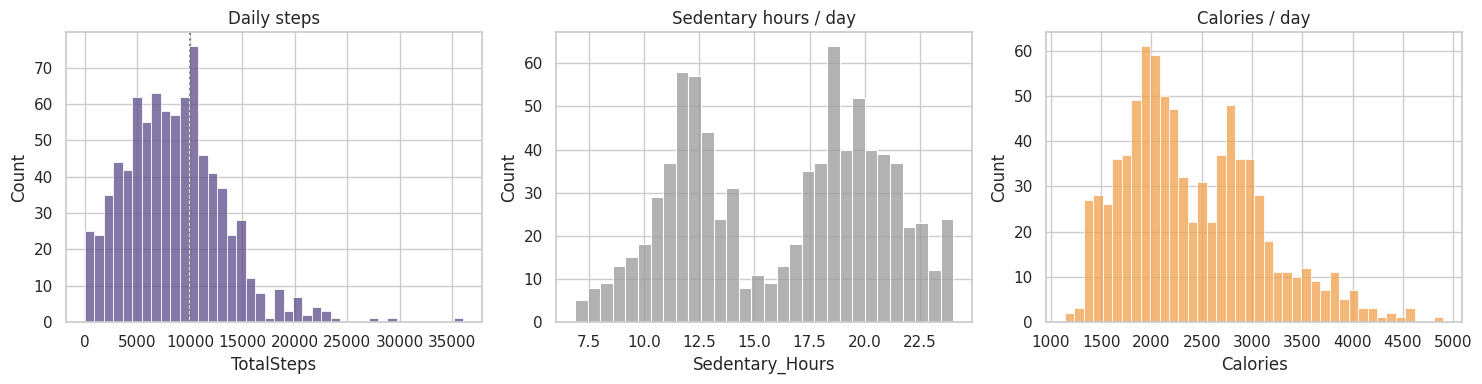

Mean steps 8,494 | share of days >= 10k steps: 36% | < 5k: 24%
Avg minutes/day -> sedentary 974, light 213, fairly 15, very 24


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(valid.TotalSteps, bins=40, color='#5B4B8A', ax=ax[0]); ax[0].axvline(10000, ls=':', c='grey'); ax[0].set_title('Daily steps')
sns.histplot(valid.Sedentary_Hours, bins=30, color='#999', ax=ax[1]); ax[1].set_title('Sedentary hours / day')
sns.histplot(valid.Calories, bins=40, color='#F0A04B', ax=ax[2]); ax[2].set_title('Calories / day')
plt.tight_layout(); plt.show()
print(f"Mean steps {valid.TotalSteps.mean():,.0f} | share of days >= 10k steps: {(valid.TotalSteps>=10000).mean():.0%} | < 5k: {(valid.TotalSteps<5000).mean():.0%}")
print(f"Avg minutes/day -> sedentary {valid.SedentaryMinutes.mean():.0f}, light {valid.LightlyActiveMinutes.mean():.0f}, fairly {valid.FairlyActiveMinutes.mean():.0f}, very {valid.VeryActiveMinutes.mean():.0f}")

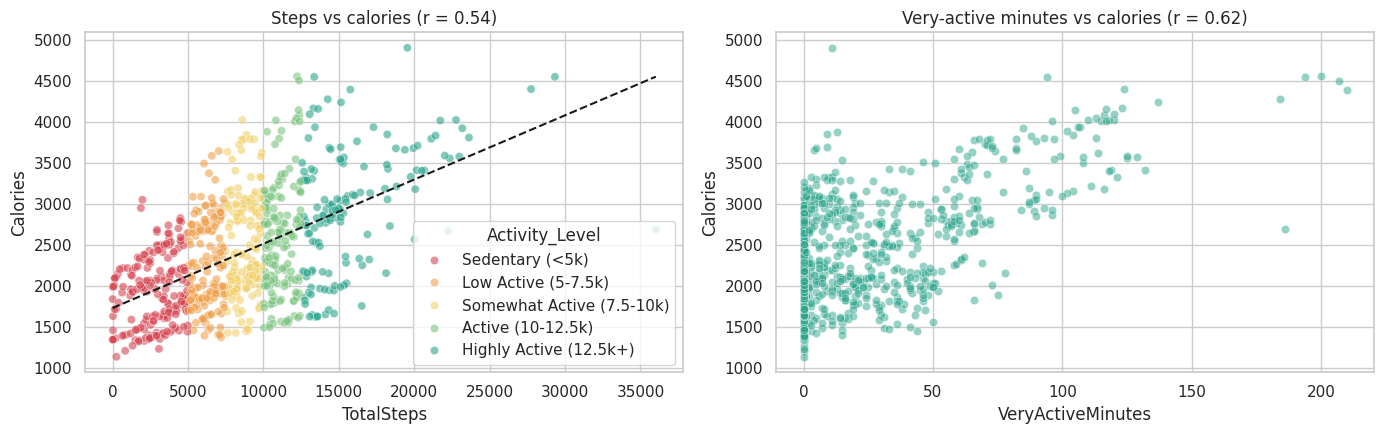

Roughly 78 extra kcal per 1,000 steps (population slope) — but body size drives the intercept, hence the wide scatter.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(data=valid, x='TotalSteps', y='Calories', hue='Activity_Level', hue_order=LEVELS, palette=PAL, alpha=.6, ax=ax[0])
b, a = np.polyfit(valid.TotalSteps, valid.Calories, 1); xs = np.array([0, valid.TotalSteps.max()]); ax[0].plot(xs, a + b*xs, 'k--')
ax[0].set_title(f"Steps vs calories (r = {valid.TotalSteps.corr(valid.Calories):.2f})")
sns.scatterplot(data=valid, x='VeryActiveMinutes', y='Calories', alpha=.5, color='#2CA58D', ax=ax[1])
ax[1].set_title(f"Very-active minutes vs calories (r = {valid.VeryActiveMinutes.corr(valid.Calories):.2f})")
plt.tight_layout(); plt.show()
print('Roughly', int(round(b*1000)), 'extra kcal per 1,000 steps (population slope) — but body size drives the intercept, hence the wide scatter.')

/tmp/ipykernel_207/718459620.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='Day_Type', y='TotalSteps', palette=['#5B4B8A', '#2CA58D'], ax=ax[1]); ax[1].set_title('Weekday vs weekend')


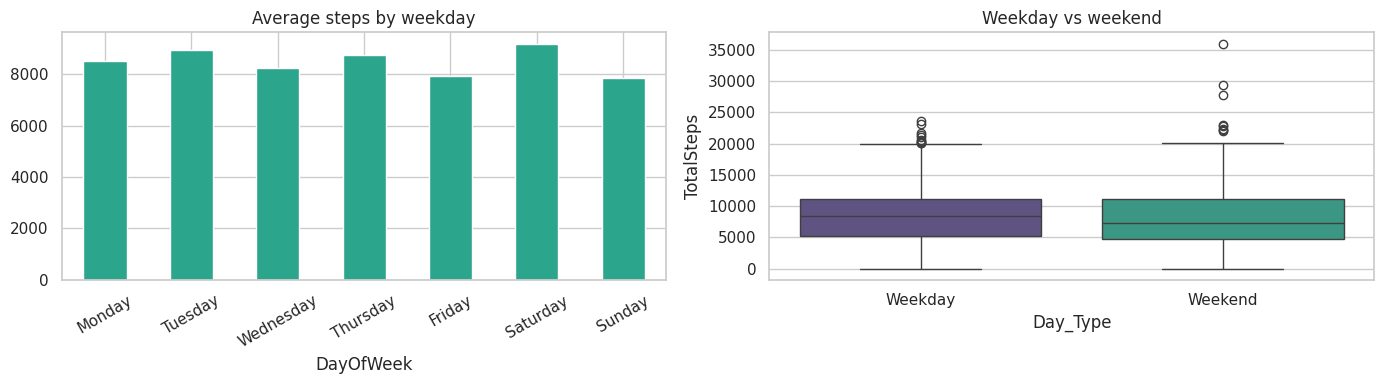

{'Monday': 8525.0, 'Tuesday': 8949.0, 'Wednesday': 8242.0, 'Thursday': 8755.0, 'Friday': 7920.0, 'Saturday': 9171.0, 'Sunday': 7845.0}
{'Weekday': 8485.0, 'Weekend': 8521.0}


In [9]:
dow = valid.groupby('DayOfWeek').TotalSteps.mean().reindex(DOW)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
dow.plot(kind='bar', color='#2CA58D', ax=ax[0]); ax[0].set_title('Average steps by weekday'); ax[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=valid, x='Day_Type', y='TotalSteps', palette=['#5B4B8A', '#2CA58D'], ax=ax[1]); ax[1].set_title('Weekday vs weekend')
plt.tight_layout(); plt.show()
print(dow.round(0).to_dict()); print(valid.groupby('Day_Type').TotalSteps.mean().round(0).to_dict())

## 5. Time of day

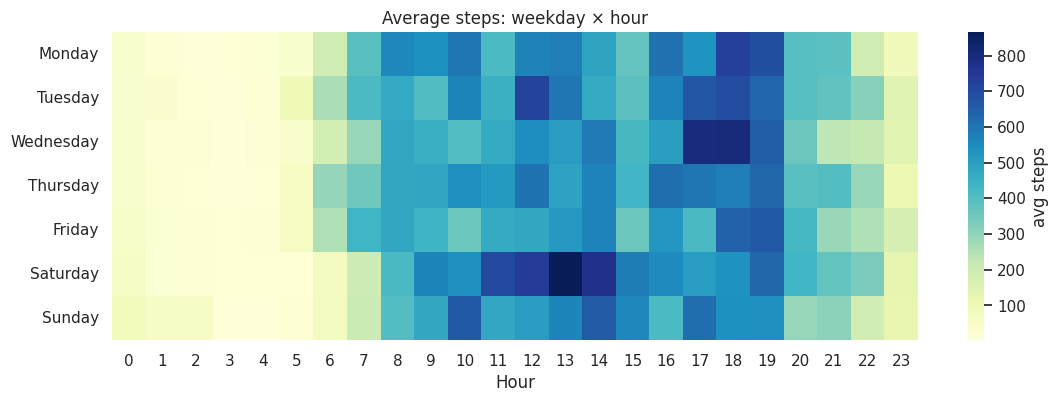

Peak hours: {18: 653.0, 19: 636.0, 17: 600.0}
{'Afternoon (12-16)': 32.8, 'Evening (17-20)': 27.0, 'Late (21-23)': 8.6, 'Morning (6-11)': 29.7, 'Night (0-5)': 1.9}


In [10]:
hv = hourly[hourly.Valid_Day]
piv = hv.groupby(['DayOfWeek', 'Hour']).StepTotal.mean().unstack().reindex(DOW)
plt.figure(figsize=(13, 4)); sns.heatmap(piv, cmap='YlGnBu', cbar_kws={'label': 'avg steps'}); plt.title('Average steps: weekday × hour'); plt.ylabel(''); plt.show()
hh = hv.groupby('Hour').StepTotal.mean()
print('Peak hours:', hh.sort_values(ascending=False).head(3).round(0).to_dict())
print((hv.groupby('Time_Of_Day').StepTotal.sum() / hv.StepTotal.sum() * 100).round(1).to_dict())

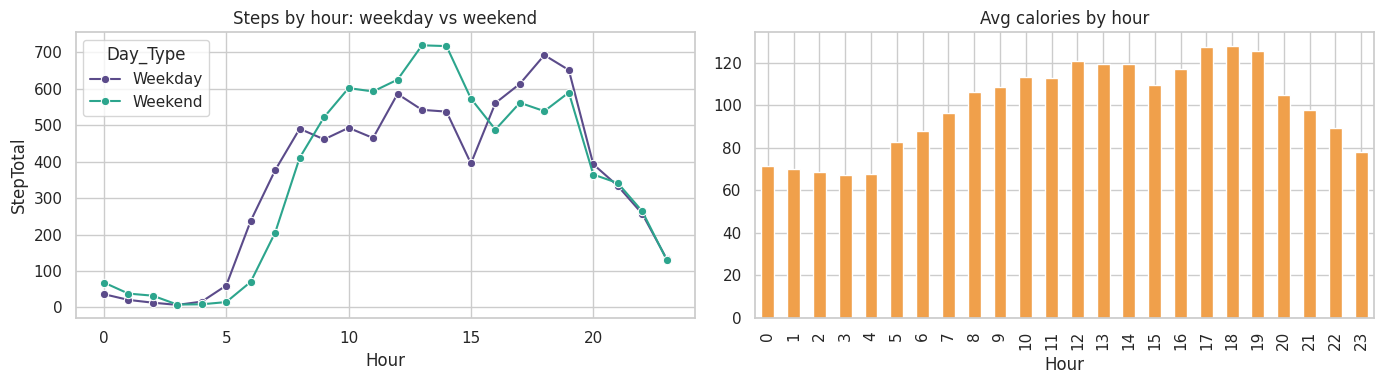

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=hv, x='Hour', y='StepTotal', hue='Day_Type', errorbar=None, marker='o', palette=['#5B4B8A', '#2CA58D'], ax=ax[0]); ax[0].set_title('Steps by hour: weekday vs weekend')
hv.groupby('Hour')[['Calories']].mean().plot(kind='bar', color='#F0A04B', ax=ax[1], legend=False); ax[1].set_title('Avg calories by hour')
plt.tight_layout(); plt.show()

## 6. Sleep

390 nights, 23 users | avg 6.89 h | <7h on 46% of nights | efficiency 91.8% | nap/multi-record days 11%


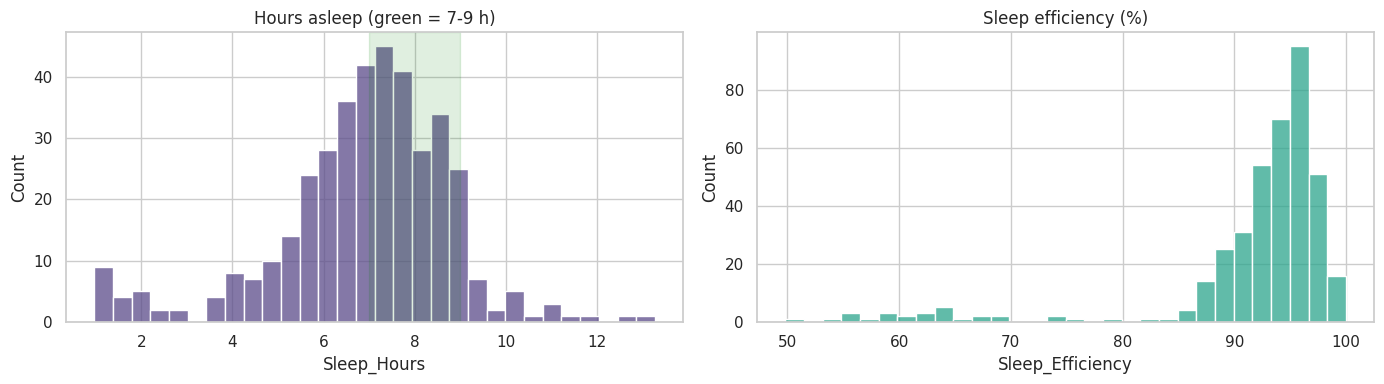

In [12]:
s = valid[valid.Has_Sleep].copy()
print(f"{len(s)} nights, {s.Id.nunique()} users | avg {s.Sleep_Hours.mean():.2f} h | <7h on {(s.Sleep_Hours<7).mean():.0%} of nights | efficiency {s.Sleep_Efficiency.mean():.1f}% | nap/multi-record days {s.Is_Nap_Day.mean():.0%}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(s.Sleep_Hours, bins=30, color='#5B4B8A', ax=ax[0]); ax[0].axvspan(7, 9, color='green', alpha=.12); ax[0].set_title('Hours asleep (green = 7-9 h)')
sns.histplot(s.Sleep_Efficiency, bins=30, color='#2CA58D', ax=ax[1]); ax[1].set_title('Sleep efficiency (%)')
plt.tight_layout(); plt.show()

/tmp/ipykernel_207/4256390692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x='Activity_Level', y='Sleep_Hours', order=LEVELS, palette=PAL, ax=ax[2]); ax[2].set_title('Sleep by activity level'); ax[2].tick_params(axis='x', rotation=25)


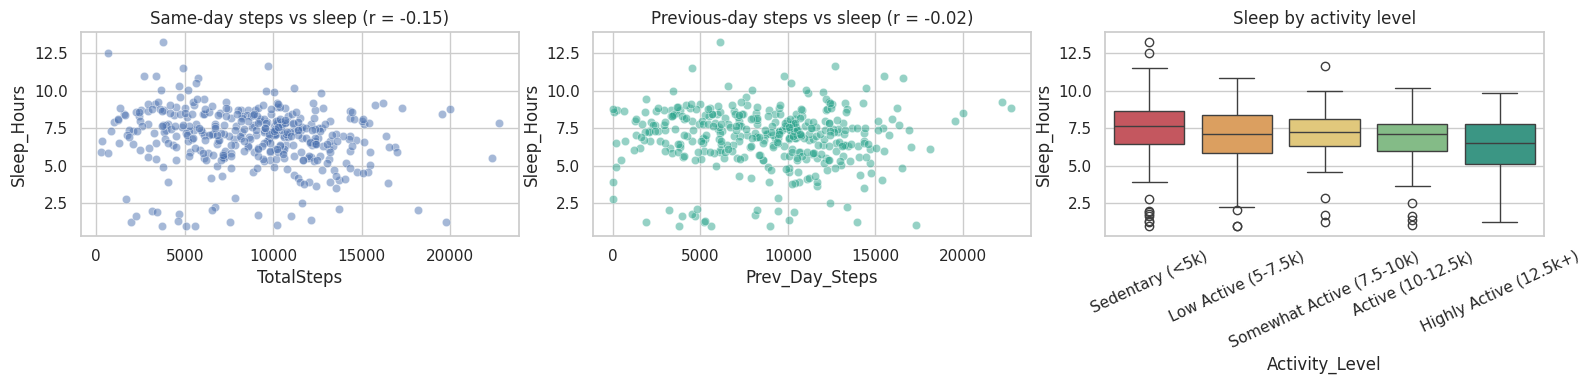

Sleep vs sedentary hours r = -0.67 (largely a measurement effect: time in bed counts as sedentary)
{'Monday': 6.96, 'Tuesday': 6.74, 'Wednesday': 7.25, 'Thursday': 6.59, 'Friday': 6.68, 'Saturday': 6.72, 'Sunday': 7.31}


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=s, x='TotalSteps', y='Sleep_Hours', alpha=.5, ax=ax[0]); ax[0].set_title(f"Same-day steps vs sleep (r = {s.TotalSteps.corr(s.Sleep_Hours):.2f})")
sns.scatterplot(data=s, x='Prev_Day_Steps', y='Sleep_Hours', alpha=.5, color='#2CA58D', ax=ax[1]); ax[1].set_title(f"Previous-day steps vs sleep (r = {s.Prev_Day_Steps.corr(s.Sleep_Hours):.2f})")
sns.boxplot(data=s, x='Activity_Level', y='Sleep_Hours', order=LEVELS, palette=PAL, ax=ax[2]); ax[2].set_title('Sleep by activity level'); ax[2].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()
print('Sleep vs sedentary hours r =', round(s.Sleep_Hours.corr(s.Sedentary_Hours), 2), '(largely a measurement effect: time in bed counts as sedentary)')
print(s.groupby('DayOfWeek').Sleep_Hours.mean().reindex(DOW).round(2).to_dict())

## 7. Users & segments

{'Sedentary (<5k)': 7, 'Low Active (5-7.5k)': 8, 'Somewhat Active (7.5-10k)': 8, 'Active (10-12.5k)': 7, 'Highly Active (12.5k+)': 3}
{'High (25+ days)': 21, 'Moderate (15-24)': 11, 'Low (<15 days)': 1}
Meet WHO guideline proxy: 70% of users | average < 7,500 steps: 45%


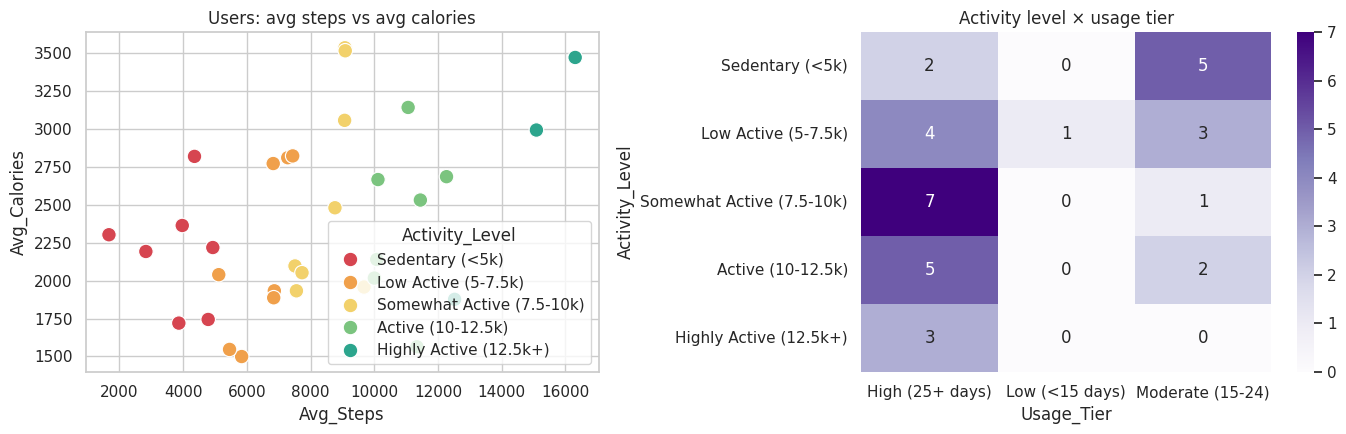

In [14]:
print(users.Activity_Level.value_counts().reindex(LEVELS).to_dict())
print(users.Usage_Tier.value_counts().to_dict())
print(f"Meet WHO guideline proxy: {users.Meets_WHO_Guideline.mean():.0%} of users | average < 7,500 steps: {(users.Avg_Steps < 7500).mean():.0%}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(data=users, x='Avg_Steps', y='Avg_Calories', hue='Activity_Level', hue_order=LEVELS, palette=PAL, s=110, ax=ax[0]); ax[0].set_title('Users: avg steps vs avg calories')
pd.crosstab(users.Activity_Level, users.Usage_Tier).reindex(LEVELS).pipe(lambda t: sns.heatmap(t, annot=True, fmt='d', cmap='Purples', ax=ax[1])); ax[1].set_title('Activity level × usage tier')
plt.tight_layout(); plt.show()

In [15]:
users[['User','Valid_Days','Avg_Steps','Avg_Calories','Avg_Sedentary_Hours','Avg_Sleep_Hours','Activity_Level','Usage_Tier','Meets_WHO_Guideline']].round(1).sort_values('Avg_Steps', ascending=False).head(10)

,User,Valid_Days,Avg_Steps,Avg_Calories,Avg_Sedentary_Hours,Avg_Sleep_Hours,Activity_Level,Usage_Tier,Meets_WHO_Guideline
32,User 33,30,16305.9,3472.6,18.7,NaN,Highly Active (12.5k+),High (25+ days),True
27,User 28,30,15088.8,2993.8,19.3,5.0,Highly Active (12.5k+),High (25+ days),True
0,User 01,30,12520.6,1877.0,13.8,6.0,Highly Active (12.5k+),High (25+ days),True
25,User 26,24,12267.0,2686.1,18.0,1.1,Active (10-12.5k),Moderate (15-24),True
5,User 06,30,11445.8,2531.9,18.8,NaN,Active (10-12.5k),High (25+ days),True
11,User 12,29,11337.6,1564.1,12.2,4.9,Active (10-12.5k),High (25+ days),True
15,User 16,30,11062.1,3142.9,14.0,6.7,Active (10-12.5k),High (25+ days),True
26,User 27,28,10114.9,2667.1,14.3,7.4,Active (10-12.5k),High (25+ days),True
8,User 09,17,10077.2,2139.9,12.1,7.5,Active (10-12.5k),Moderate (15-24),True
24,User 25,30,10001.7,2017.2,11.3,7.4,Active (10-12.5k),High (25+ days),True


## 8. Heart rate & weight (small samples)

HR users: 14 | user-hours: 6006


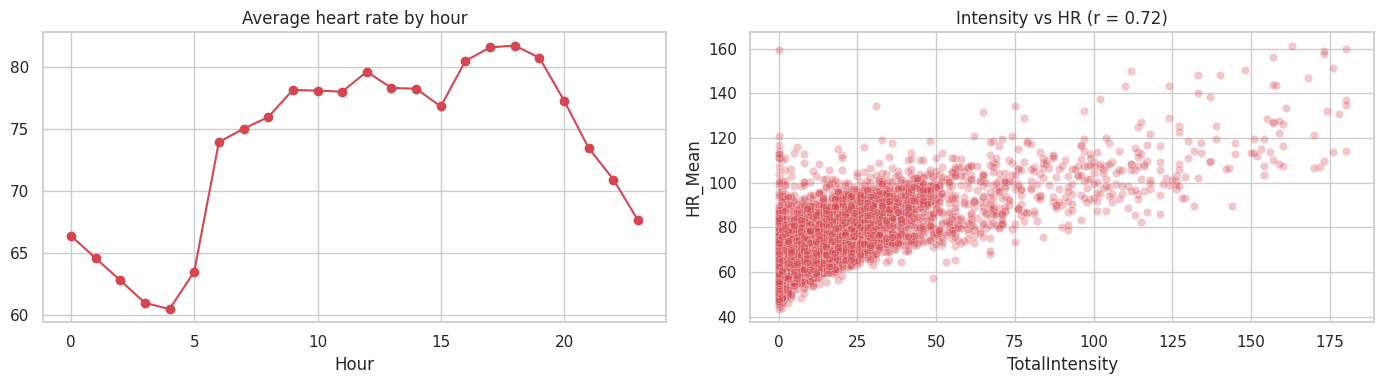

In [16]:
hr = hourly[hourly.HR_Mean.notna()]
print('HR users:', hr.Id.nunique(), '| user-hours:', len(hr))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
hr.groupby('Hour').HR_Mean.mean().plot(marker='o', color='#D64550', ax=ax[0]); ax[0].set_title('Average heart rate by hour')
sns.scatterplot(data=hr, x='TotalIntensity', y='HR_Mean', alpha=.3, color='#D64550', ax=ax[1]); ax[1].set_title(f"Intensity vs HR (r = {hr.TotalIntensity.corr(hr.HR_Mean):.2f})")
plt.tight_layout(); plt.show()

In [17]:
print('Weight users:', weight.User.nunique(), '| entries:', len(weight), '| manual entries:', f"{weight.IsManualReport.astype(str).str.lower().isin(['true','1']).mean():.0%}")
print(weight.groupby('User').BMI.mean().round(1).sort_values().to_dict())

Weight users: 8 | entries: 67 | manual entries: 61%
{'User 10': 21.6, 'User 01': 22.6, 'User 25': 24.0, 'User 33': 25.5, 'User 18': 27.2, 'User 15': 27.4, 'User 21': 28.0, 'User 05': 47.5}


## 9. Correlations

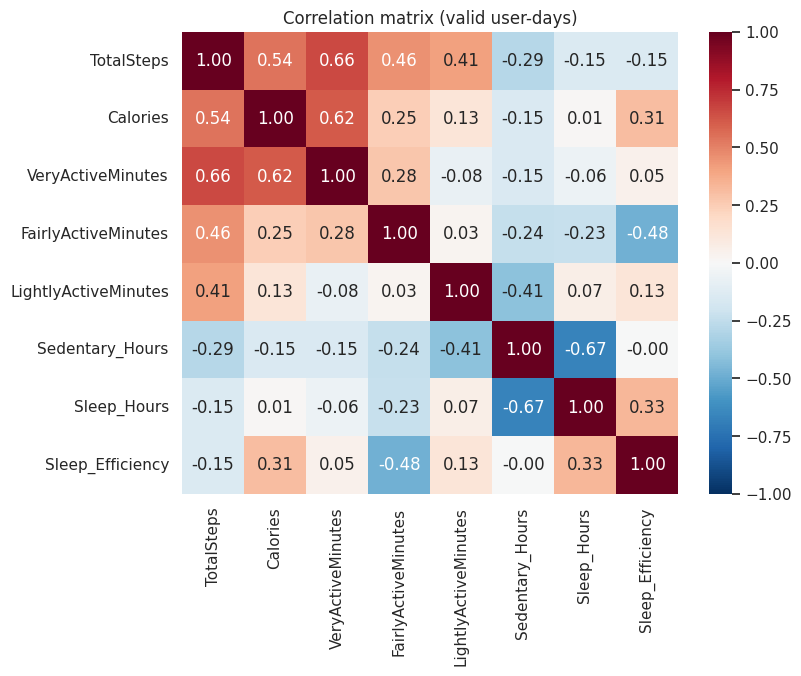

In [18]:
cols = ['TotalSteps','Calories','VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','Sedentary_Hours','Sleep_Hours','Sleep_Efficiency']
plt.figure(figsize=(8, 6)); sns.heatmap(valid[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1); plt.title('Correlation matrix (valid user-days)'); plt.show()

## 10. Key findings
- **Activity is moderate, and sedentary time dominates.** Mean 8,494 steps/day; only 36% of valid days reach 10,000 steps and 24% fall under 5,000. Users spend ~16 tracked hours/day sedentary vs ~24 very-active minutes.
- **Segments are evenly spread:** 7 Sedentary, 8 Low Active, 8 Somewhat Active, 7 Active, 3 Highly Active users. ~70% meet a WHO-equivalent activity guideline (driven by vigorous minutes), yet ~45% average under 7,500 steps.
- **Weekday barely differs from weekend** (8,485 vs 8,521 steps); Saturday is the most active day (9,171) and Sunday the least (7,845).
- **Movement peaks 5–7 pm** (18:00 is the top hour); afternoon (33%), morning (30%) and evening (27%) each carry roughly a third of steps; overnight is ~2%.
- **Sleep is short but efficient:** 6.9 h on average, <7 h on 46% of nights, yet 92% efficiency. Steps show almost no relationship with sleep (r ≈ −0.15 same day, ≈ 0 previous day); the most active users actually sleep the least (Highly Active: 6.4 h).
- **Steps explain only part of calorie burn** (r = 0.54); very-active minutes are a stronger driver (r = 0.62), and hourly intensity tracks heart rate well (r = 0.72, 14 users).
- **Engagement gaps:** 24/33 users track sleep, 14/33 have heart-rate data, only 8/33 log weight (61% of entries manual). Non-wear/partial days make up ~11% of user-days.

**Limitations:** 33 self-selected users, 30 days, 2016 data; subgroup results (esp. heart rate, weight, Highly Active users) rest on very few people; the steps-band segmentation and WHO proxy are approximations; sleep is attributed to the day the night *ends*.

**Recommendations:** move-reminders for long sedentary stretches; time nudges just before the 5–7 pm peak; goals tailored by segment (step ramps for Sedentary/Low Active, intensity goals for Active); sleep-routine features to lift short sleep; reduce friction for weight/sleep logging to raise adoption.

## 11. Export

In [19]:
app.save_outputs(daily, hourly, users, weight, dq)
print('Done. Launch the dashboard with:  streamlit run dashboard.py')

Saved DB -> /home/claude/fitbit_project/db/fitbit.db and CSVs -> /home/claude/fitbit_project/data/processed
Done. Launch the dashboard with:  streamlit run dashboard.py
